# Brain Tumor Segmentation from Multi-Modal MRI using Attention U-Net and U-Net Comparison

This Kaggle notebook is divided into sections for BraTS 2020 H5-format datasets. It trains Attention U-Net as the main model, adds a standard U-Net as a comparison model, reloads saved Attention U-Net weights, tests on random images, saves plots/metrics/weights, and creates a final ZIP file for download.


In [13]:
# ==========================================================
# Section 1: Environment Setup
# ==========================================================

import os, glob, json, random, zipfile
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = "/kaggle/working/brats_attention_unet_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [14]:
# ==========================================================
# Section 2: Dataset Path and File Collection
# ==========================================================

# Recommended Kaggle dataset:
# BraTS 2020 Training Data by awsaf49
# Add it to Kaggle notebook input, then run this code.

CANDIDATE_PATHS = [
    "/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data",
    "/kaggle/input/brats2020-training-data",
    "/kaggle/input"
]

DATASET_DIR = None
for p in CANDIDATE_PATHS:
    if os.path.exists(p):
        h5_files = glob.glob(os.path.join(p, "**", "*.h5"), recursive=True)
        if len(h5_files) > 0:
            DATASET_DIR = p
            break

if DATASET_DIR is None:
    raise FileNotFoundError("No .h5 BraTS files found. Please add BraTS 2020 Training Data to Kaggle input.")

all_files = sorted(glob.glob(os.path.join(DATASET_DIR, "**", "*.h5"), recursive=True))
print("Dataset directory:", DATASET_DIR)
print("Total H5 slice files found:", len(all_files))
print("First file:", all_files[0])

# Reduce for quick testing if needed. Set to None for full data.
MAX_FILES = None
if MAX_FILES is not None:
    all_files = all_files[:MAX_FILES]
    print("Using limited files:", len(all_files))


Dataset directory: /kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data
Total H5 slice files found: 57195
First file: /kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data/volume_100_slice_0.h5


In [15]:
# ==========================================================
# Section 3: Inspect One Sample
# ==========================================================

with h5py.File(all_files[0], 'r') as f:
    print("Keys:", list(f.keys()))
    image = f['image'][:]
    mask = f['mask'][:]

print("Image shape:", image.shape)  # usually (240, 240, 4)
print("Mask shape:", mask.shape)    # usually (240, 240, 3)
print("Image min/max:", image.min(), image.max())
print("Mask unique values:", np.unique(mask))


Keys: ['image', 'mask']
Image shape: (240, 240, 4)
Mask shape: (240, 240, 3)
Image min/max: 0.0 0.0
Mask unique values: [0]


In [16]:
# ==========================================================
# Section 4: Data Loader
# ==========================================================

IMG_HEIGHT = 128
IMG_WIDTH = 128
IMG_CHANNELS = 4       # FLAIR, T1, T1CE, T2
MASK_CHANNELS = 3      # BraTS tumor sub-regions in H5 format
BATCH_SIZE = 8
EPOCHS = 5


def load_h5_file(path):
    with h5py.File(path, 'r') as f:
        image = f['image'][:].astype(np.float32)
        mask = f['mask'][:].astype(np.float32)

    # Resize to 128x128 for faster Kaggle training
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH)).numpy()
    mask = tf.image.resize(mask, (IMG_HEIGHT, IMG_WIDTH), method='nearest').numpy()

    # Normalize each image slice safely
    image = (image - np.mean(image)) / (np.std(image) + 1e-8)

    mask = (mask > 0.5).astype(np.float32)
    return image, mask


def data_generator(file_list):
    for path in file_list:
        image, mask = load_h5_file(path)
        yield image, mask


def make_dataset(file_list, batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_generator(
        lambda: data_generator(file_list),
        output_signature=(
            tf.TensorSpec(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=tf.float32),
            tf.TensorSpec(shape=(IMG_HEIGHT, IMG_WIDTH, MASK_CHANNELS), dtype=tf.float32)
        )
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(file_list), 1000), seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_files, temp_files = train_test_split(all_files, test_size=0.30, random_state=SEED)
val_files, test_files = train_test_split(temp_files, test_size=0.50, random_state=SEED)

print("Training files:", len(train_files))
print("Validation files:", len(val_files))
print("Testing files:", len(test_files))

train_ds = make_dataset(train_files, shuffle=True)
val_ds = make_dataset(val_files, shuffle=False)
test_ds = make_dataset(test_files, shuffle=False)


Training files: 40036
Validation files: 8579
Testing files: 8580


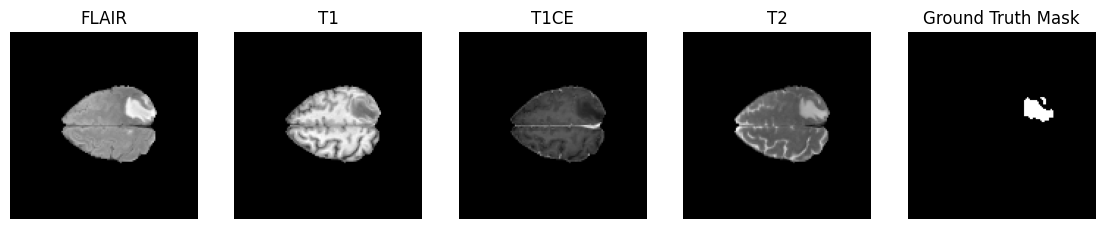

In [17]:
# ==========================================================
# Section 5: Visualize MRI and Mask
# ==========================================================

def show_sample(file_path, save_path=None):
    image, mask = load_h5_file(file_path)
    flair = image[:, :, 0]
    t1 = image[:, :, 1]
    t1ce = image[:, :, 2]
    t2 = image[:, :, 3]
    combined_mask = np.max(mask, axis=-1)

    plt.figure(figsize=(14, 4))
    titles = ["FLAIR", "T1", "T1CE", "T2", "Ground Truth Mask"]
    imgs = [flair, t1, t1ce, t2, combined_mask]
    for i, (im, title) in enumerate(zip(imgs, titles)):
        plt.subplot(1, 5, i + 1)
        plt.imshow(im, cmap='gray')
        plt.title(title)
        plt.axis('off')
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

show_sample(train_files[0], os.path.join(OUTPUT_DIR, "sample_modalities_and_mask.png"))


In [18]:
# ==========================================================
# Section 6: Metrics and Loss Functions
# ==========================================================

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)


def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


In [19]:
# ==========================================================
# Section 7: Attention U-Net Architecture
# ==========================================================

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x


def attention_gate(skip, gating, filters):
    theta_x = layers.Conv2D(filters, 1, padding='same')(skip)
    phi_g = layers.Conv2D(filters, 1, padding='same')(gating)
    add = layers.Add()([theta_x, phi_g])
    act = layers.Activation('relu')(add)
    psi = layers.Conv2D(1, 1, padding='same')(act)
    psi = layers.Activation('sigmoid')(psi)
    return layers.Multiply()([skip, psi])


def build_attention_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes=MASK_CHANNELS):
    inputs = layers.Input(input_shape)

    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 256)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    bottleneck = conv_block(p4, 512)

    u4 = layers.UpSampling2D((2, 2))(bottleneck)
    a4 = attention_gate(c4, u4, 256)
    u4 = layers.Concatenate()([u4, a4])
    c5 = conv_block(u4, 256)

    u3 = layers.UpSampling2D((2, 2))(c5)
    a3 = attention_gate(c3, u3, 128)
    u3 = layers.Concatenate()([u3, a3])
    c6 = conv_block(u3, 128)

    u2 = layers.UpSampling2D((2, 2))(c6)
    a2 = attention_gate(c2, u2, 64)
    u2 = layers.Concatenate()([u2, a2])
    c7 = conv_block(u2, 64)

    u1 = layers.UpSampling2D((2, 2))(c7)
    a1 = attention_gate(c1, u1, 32)
    u1 = layers.Concatenate()([u1, a1])
    c8 = conv_block(u1, 32)

    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(c8)
    return models.Model(inputs, outputs, name='Attention_UNet_BraTS')

model = build_attention_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coef, iou_coef, 'binary_accuracy']
)
model.summary()


Model: "Attention_UNet_BraTS"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 128, 128,  │      1,184 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_26       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 128, 128,  │      9,248 │ activation_26[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_27       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ activation_27[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_33[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_28       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 64, 64,    │     36,928 │ activation_28[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_34[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_29       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ activation_29[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_35[0][0] 

 Total params: 8,121,351 (30.98 MB)

 Trainable params: 8,115,463 (30.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [20]:
# ==========================================================
# Section 8: Train Attention U-Net
# ==========================================================

callbacks = [
    EarlyStopping(monitor='val_dice_coef', patience=8, mode='max', restore_best_weights=True),
    ModelCheckpoint(os.path.join(OUTPUT_DIR, 'attention_unet_best_model.keras'),
                    monitor='val_dice_coef', mode='max', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7),
    CSVLogger(os.path.join(OUTPUT_DIR, 'training_log.csv'))
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

model.save(os.path.join(OUTPUT_DIR, 'attention_unet_final_model.keras'))
model.save_weights(os.path.join(OUTPUT_DIR, 'attention_unet_weights.weights.h5'))


Epoch 1/5
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 1427s 276ms/step - binary_accuracy: 0.9954 - dice_coef: 0.4024 - iou_coef: 0.2963 - loss: 0.6533 - val_binary_accuracy: 0.9982 - val_dice_coef: 0.6917 - val_iou_coef: 0.5486 - val_loss: 0.3185 - learning_rate: 1.0000e-04
Epoch 2/5
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 1251s 246ms/step - binary_accuracy: 0.9983 - dice_coef: 0.7250 - iou_coef: 0.5891 - loss: 0.2848 - val_binary_accuracy: 0.9977 - val_dice_coef: 0.6879 - val_iou_coef: 0.5428 - val_loss: 0.3243 - learning_rate: 1.0000e-04
Epoch 3/5
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 1322s 261ms/step - binary_accuracy: 0.9984 - dice_coef: 0.7467 - iou_coef: 0.6171 - loss: 0.2627 - val_binary_accuracy: 0.9985 - val_dice_coef: 0.7597 - val_iou_coef: 0.6317 - val_loss: 0.2496 - learning_rate: 1.0000e-04
Epoch 4/5
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 1316s 259ms/step - binary_accuracy: 0.9985 - dice_coef: 0.7618 - iou_coef: 0.6356 - loss: 0.2472 - val_binary_accuracy: 0.9985 - val_dice_coef: 0.7684 - val_iou_coef: 0.6438

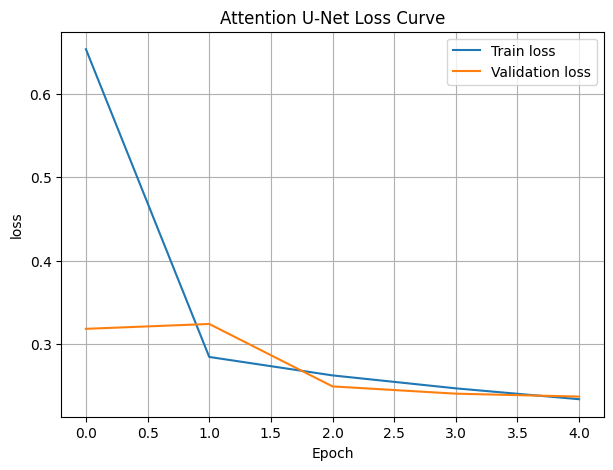

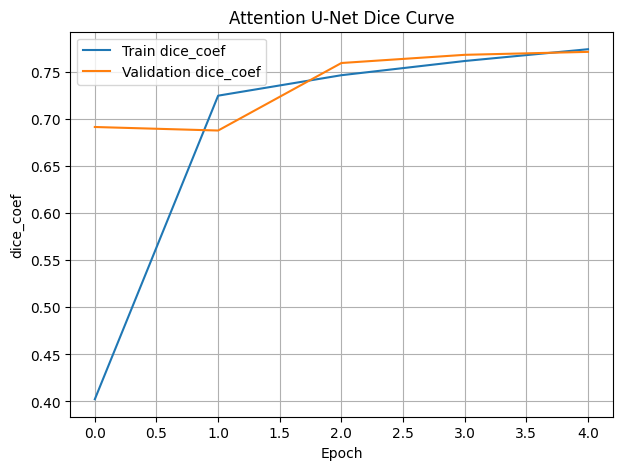

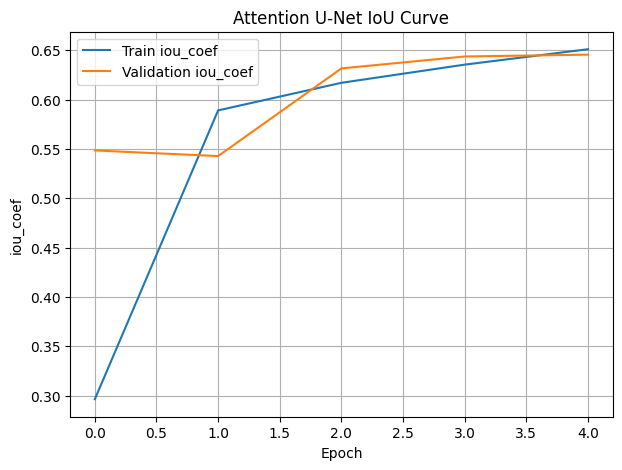

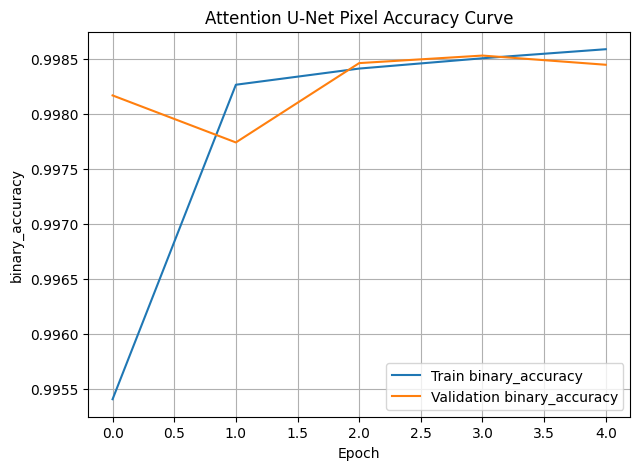

In [21]:
# ==========================================================
# Section 9: Plot Training Curves
# ==========================================================

def plot_history(history, metric, title, filename):
    plt.figure(figsize=(7, 5))
    plt.plot(history.history[metric], label=f'Train {metric}')
    plt.plot(history.history['val_' + metric], label=f'Validation {metric}')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300, bbox_inches='tight')
    plt.show()

plot_history(history, 'loss', 'Attention U-Net Loss Curve', 'loss_curve.png')
plot_history(history, 'dice_coef', 'Attention U-Net Dice Curve', 'dice_curve.png')
plot_history(history, 'iou_coef', 'Attention U-Net IoU Curve', 'iou_curve.png')
plot_history(history, 'binary_accuracy', 'Attention U-Net Pixel Accuracy Curve', 'pixel_accuracy_curve.png')


In [23]:
# ==========================================================
# Section 10: Testing and Quantitative Evaluation
# ==========================================================

import os
import json

# Evaluate model on test dataset
test_results = model.evaluate(test_ds, verbose=1)

# Store metrics in dictionary
metric_names = model.metrics_names
metrics_dict = {
    name: float(value)
    for name, value in zip(metric_names, test_results)
}

# Print results
print("\nTesting Results")
for k, v in metrics_dict.items():
    print(f"{k}: {v:.4f}")

# Save metrics as JSON
with open(os.path.join(OUTPUT_DIR, "test_metrics.json"), "w") as f:
    json.dump(metrics_dict, f, indent=4)

# Save summary text file
with open(os.path.join(OUTPUT_DIR, "test_results_summary.txt"), "w") as f:
    f.write("BraTS Brain Tumor Segmentation using Attention U-Net\n")
    f.write("===============================================\n")
    f.write("Testing Results\n\n")

    for k, v in metrics_dict.items():
        f.write(f"{k}: {v:.4f}\n")

print("\nTest evaluation completed successfully.")
print(f"Results saved to: {OUTPUT_DIR}")

1073/1073 ━━━━━━━━━━━━━━━━━━━━ 187s 174ms/step - binary_accuracy: 0.9985 - dice_coef: 0.7664 - iou_coef: 0.6411 - loss: 0.2423

Testing Results
loss: 0.2423
compile_metrics: 0.7664

Test evaluation completed successfully.
Results saved to: /kaggle/working/brats_attention_unet_results


Saved Attention U-Net loaded successfully.
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 179s 164ms/step - binary_accuracy: 0.9985 - dice_coef: 0.7664 - iou_coef: 0.6411 - loss: 0.2423

Loaded Attention U-Net Testing Results
loss: 0.2423
compile_metrics: 0.7664


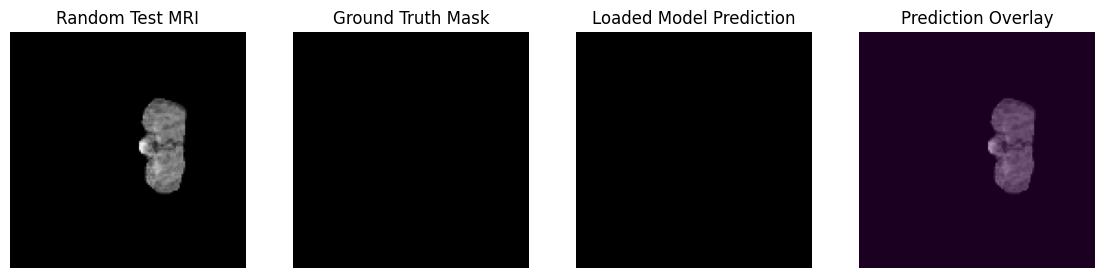

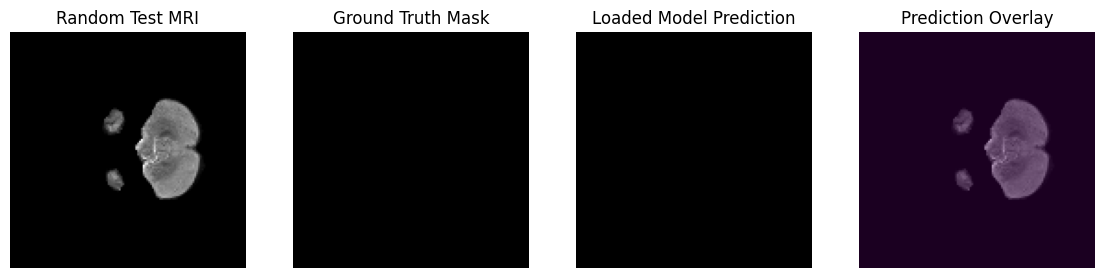

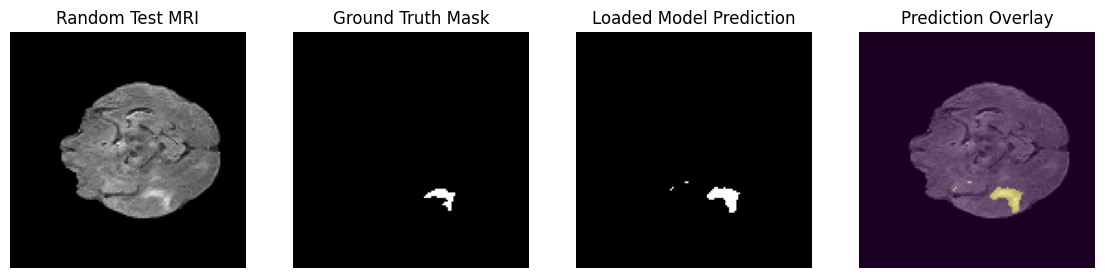

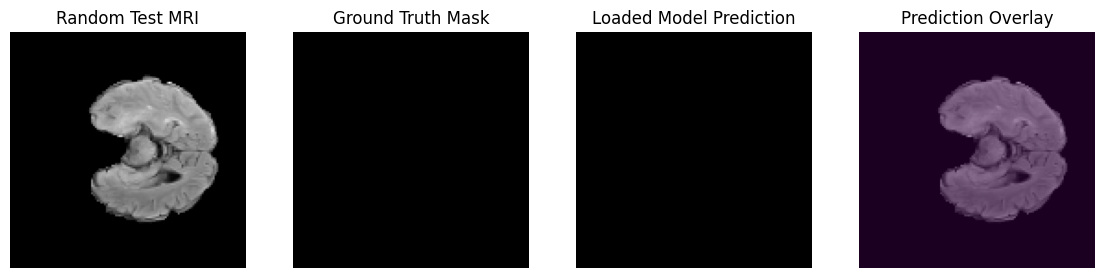

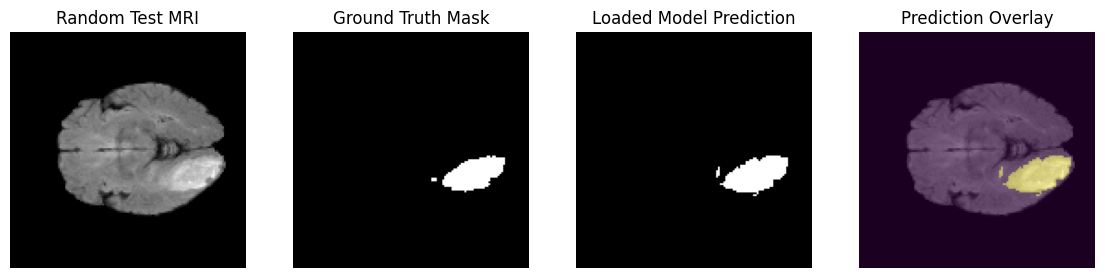

In [24]:
# ==========================================================
# Section 10A: Load Saved Attention U-Net Weights and Test Random Images
# ==========================================================

# This section is useful when training is finished and you want to reload the best saved model/weights
# and test it on random unseen testing slices.

best_model_path = os.path.join(OUTPUT_DIR, 'attention_unet_best_model.keras')
weights_path = os.path.join(OUTPUT_DIR, 'attention_unet_weights.weights.h5')

# Option 1: load the full saved model with custom loss/metrics
loaded_attention_model = tf.keras.models.load_model(
    best_model_path,
    custom_objects={
        'bce_dice_loss': bce_dice_loss,
        'dice_coef': dice_coef,
        'iou_coef': iou_coef
    }
)

# Option 2: build the architecture again and load only weights
# loaded_attention_model = build_attention_unet()
# loaded_attention_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
#                                loss=bce_dice_loss,
#                                metrics=[dice_coef, iou_coef, 'binary_accuracy'])
# loaded_attention_model.load_weights(weights_path)

print('Saved Attention U-Net loaded successfully.')

loaded_test_results = loaded_attention_model.evaluate(test_ds, verbose=1)
loaded_metrics_dict = {name: float(value) for name, value in zip(loaded_attention_model.metrics_names, loaded_test_results)}

print('\nLoaded Attention U-Net Testing Results')
for k, v in loaded_metrics_dict.items():
    print(f'{k}: {v:.4f}')

with open(os.path.join(OUTPUT_DIR, 'loaded_attention_unet_test_metrics.json'), 'w') as f:
    json.dump(loaded_metrics_dict, f, indent=4)


def test_loaded_model_on_random_images(num_images=5, threshold=0.5):
    random_files = random.sample(test_files, min(num_images, len(test_files)))
    for idx, fpath in enumerate(random_files, start=1):
        image, mask = load_h5_file(fpath)
        pred = loaded_attention_model.predict(np.expand_dims(image, axis=0), verbose=0)[0]
        pred_bin = (pred > threshold).astype(np.float32)

        flair = image[:, :, 0]
        gt_mask = np.max(mask, axis=-1)
        pred_mask = np.max(pred_bin, axis=-1)

        plt.figure(figsize=(14, 4))
        plt.subplot(1, 4, 1)
        plt.imshow(flair, cmap='gray')
        plt.title('Random Test MRI')
        plt.axis('off')

        plt.subplot(1, 4, 2)
        plt.imshow(gt_mask, cmap='gray')
        plt.title('Ground Truth Mask')
        plt.axis('off')

        plt.subplot(1, 4, 3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title('Loaded Model Prediction')
        plt.axis('off')

        plt.subplot(1, 4, 4)
        plt.imshow(flair, cmap='gray')
        plt.imshow(pred_mask, alpha=0.4)
        plt.title('Prediction Overlay')
        plt.axis('off')

        save_path = os.path.join(OUTPUT_DIR, f'loaded_attention_unet_random_test_{idx}.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()


test_loaded_model_on_random_images(num_images=5)


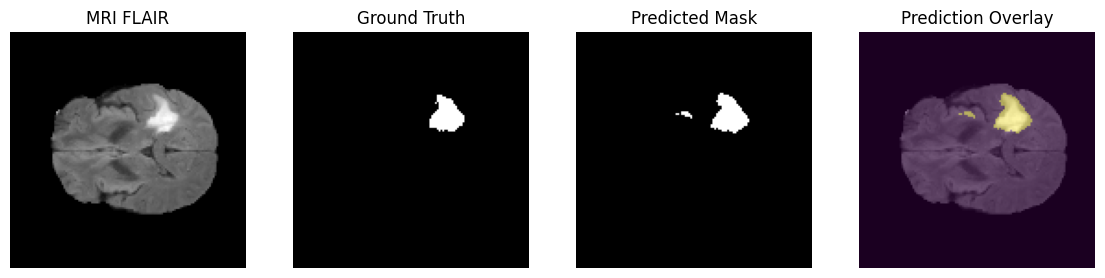

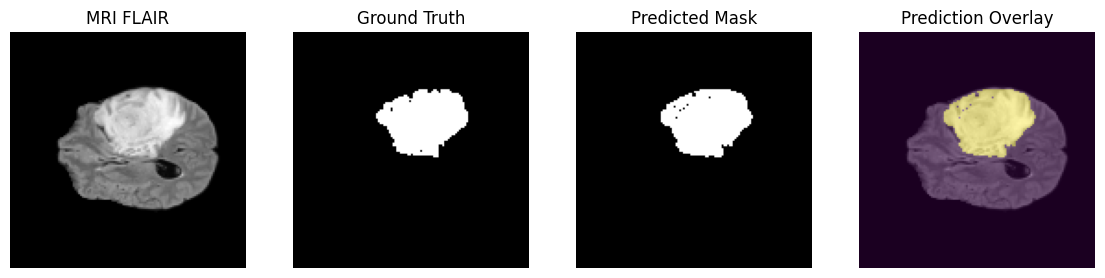

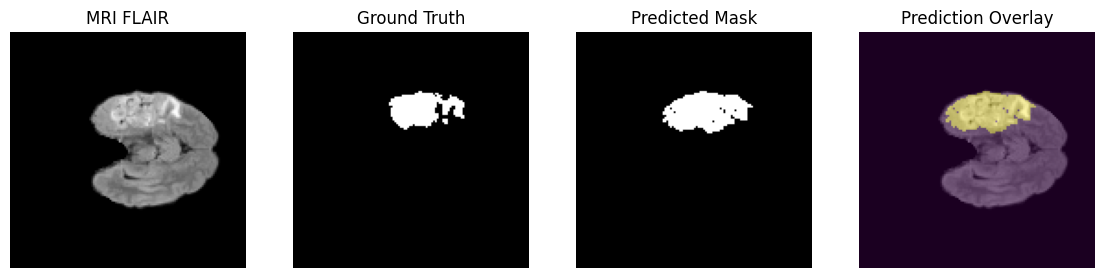

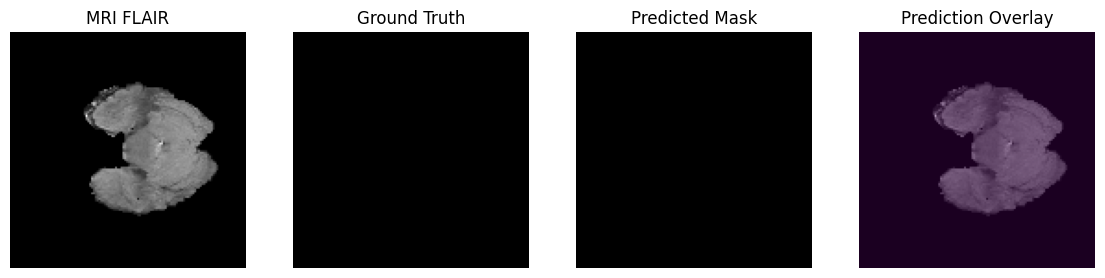

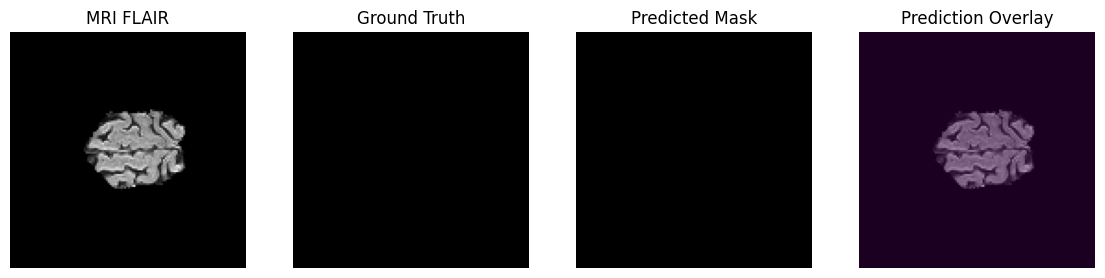

In [25]:
# ==========================================================
# Section 11: Prediction Visualization and Overlay
# ==========================================================

def visualize_prediction(file_path, idx, threshold=0.5):
    image, mask = load_h5_file(file_path)
    pred = model.predict(np.expand_dims(image, axis=0), verbose=0)[0]
    pred_bin = (pred > threshold).astype(np.float32)

    flair = image[:, :, 0]
    gt_mask = np.max(mask, axis=-1)
    pred_mask = np.max(pred_bin, axis=-1)

    plt.figure(figsize=(14, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(flair, cmap='gray')
    plt.title('MRI FLAIR')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(gt_mask, cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(pred_mask, cmap='gray')
    plt.title('Predicted Mask')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(flair, cmap='gray')
    plt.imshow(pred_mask, alpha=0.4)
    plt.title('Prediction Overlay')
    plt.axis('off')

    save_path = os.path.join(OUTPUT_DIR, f'prediction_overlay_{idx}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

for i, fpath in enumerate(test_files[:5]):
    visualize_prediction(fpath, i+1)


In [26]:
# ==========================================================
# Section 12: Save Final Project Summary
# ==========================================================

summary = f"""
Project Title: Brain Tumor Segmentation from Multi-Modal MRI using Attention U-Net

Dataset: BraTS 2020 Training Data, H5 slice format
Task: Semantic segmentation of tumor regions from MRI modalities
Input Channels: 4 MRI modalities: FLAIR, T1, T1CE, T2
Output Channels: 3 tumor mask channels
Model: Attention U-Net
Comparison Model Added Later: Standard U-Net

Why this project fits Medical Image Computing:
- Uses real medical MRI data
- Performs segmentation instead of simple classification
- Uses multi-modal medical imaging
- Evaluates with Dice coefficient and IoU
- Provides qualitative prediction overlays

Testing Results:
{json.dumps(metrics_dict, indent=4)}
"""

with open(os.path.join(OUTPUT_DIR, 'final_project_summary.txt'), 'w') as f:
    f.write(summary)

print(summary)



Project Title: Brain Tumor Segmentation from Multi-Modal MRI using Attention U-Net

Dataset: BraTS 2020 Training Data, H5 slice format
Task: Semantic segmentation of tumor regions from MRI modalities
Input Channels: 4 MRI modalities: FLAIR, T1, T1CE, T2
Output Channels: 3 tumor mask channels
Model: Attention U-Net
Comparison Model Added Later: Standard U-Net

Why this project fits Medical Image Computing:
- Uses real medical MRI data
- Performs segmentation instead of simple classification
- Uses multi-modal medical imaging
- Evaluates with Dice coefficient and IoU
- Provides qualitative prediction overlays

Testing Results:
{
    "loss": 0.2423175424337387,
    "compile_metrics": 0.7663708925247192
}



In [27]:
# ==========================================================
# Section 14: Standard U-Net Architecture for Comparison
# ==========================================================

# Standard U-Net is added as a comparison model.
# Attention U-Net is the main model, while U-Net is the baseline segmentation model.

def build_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes=MASK_CHANNELS):
    inputs = layers.Input(input_shape)

    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 256)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    bn = conv_block(p4, 512)

    u4 = layers.UpSampling2D((2, 2))(bn)
    u4 = layers.Concatenate()([u4, c4])
    c5 = conv_block(u4, 256)

    u3 = layers.UpSampling2D((2, 2))(c5)
    u3 = layers.Concatenate()([u3, c3])
    c6 = conv_block(u3, 128)

    u2 = layers.UpSampling2D((2, 2))(c6)
    u2 = layers.Concatenate()([u2, c2])
    c7 = conv_block(u2, 64)

    u1 = layers.UpSampling2D((2, 2))(c7)
    u1 = layers.Concatenate()([u1, c1])
    c8 = conv_block(u1, 32)

    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(c8)
    return models.Model(inputs, outputs, name='Standard_UNet_BraTS')

unet_model = build_unet()
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coef, iou_coef, 'binary_accuracy']
)
unet_model.summary()


Model: "Standard_UNet_BraTS"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 128, 128,  │      1,184 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_62[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_52       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 128, 128,  │      9,248 │ activation_52[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_63[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_53       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 64, 64,    │          0 │ activation_53[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_64[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_54       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 64, 64,    │     36,928 │ activation_54[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_65[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_55       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 32, 32,    │          0 │ activation_55[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_66[0][0] 

 Total params: 7,858,787 (29.98 MB)

 Trainable params: 7,852,899 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

Epoch 1/5
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 1315s 255ms/step - binary_accuracy: 0.9951 - dice_coef: 0.3599 - iou_coef: 0.2610 - loss: 0.7061 - val_binary_accuracy: 0.9982 - val_dice_coef: 0.7072 - val_iou_coef: 0.5674 - val_loss: 0.3023 - learning_rate: 1.0000e-04
Epoch 2/5
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 1245s 245ms/step - binary_accuracy: 0.9983 - dice_coef: 0.7325 - iou_coef: 0.5980 - loss: 0.2760 - val_binary_accuracy: 0.9985 - val_dice_coef: 0.7588 - val_iou_coef: 0.6301 - val_loss: 0.2494 - learning_rate: 1.0000e-04
Epoch 3/5
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 1318s 260ms/step - binary_accuracy: 0.9985 - dice_coef: 0.7593 - iou_coef: 0.6325 - loss: 0.2490 - val_binary_accuracy: 0.9985 - val_dice_coef: 0.7676 - val_iou_coef: 0.6413 - val_loss: 0.2413 - learning_rate: 1.0000e-04
Epoch 4/5
5005/5005 ━━━━━━━━━━━━━━━━━━━━ 1271s 250ms/step - binary_accuracy: 0.9986 - dice_coef: 0.7751 - iou_coef: 0.6516 - loss: 0.2330 - val_binary_accuracy: 0.9987 - val_dice_coef: 0.7922 - val_iou_coef: 0.6743

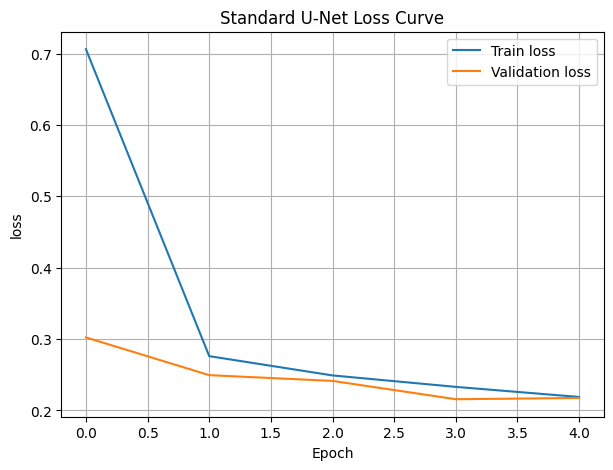

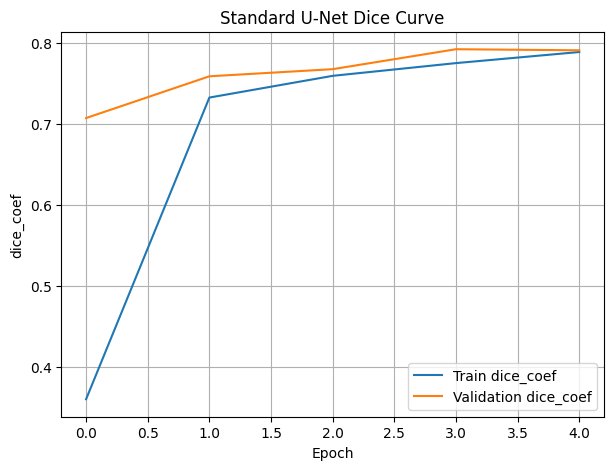

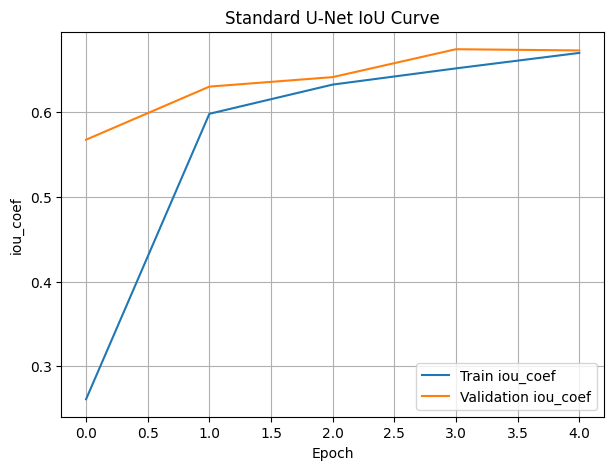

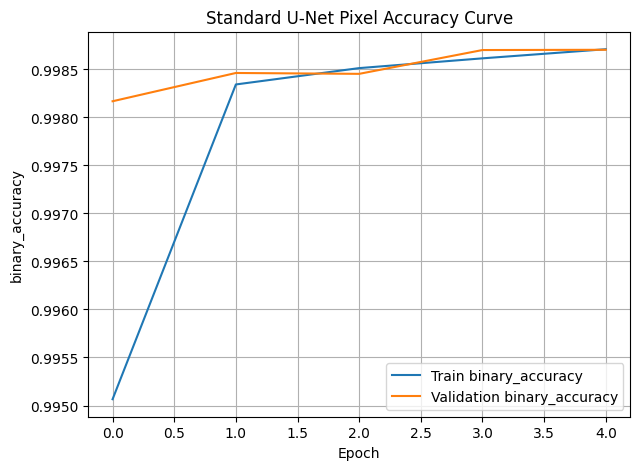

In [28]:
# ==========================================================
# Section 15: Train Standard U-Net Comparison Model
# ==========================================================

UNET_EPOCHS = 5

unet_callbacks = [
    EarlyStopping(monitor='val_dice_coef', patience=8, mode='max', restore_best_weights=True),
    ModelCheckpoint(os.path.join(OUTPUT_DIR, 'standard_unet_best_model.keras'),
                    monitor='val_dice_coef', mode='max', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7),
    CSVLogger(os.path.join(OUTPUT_DIR, 'standard_unet_training_log.csv'))
]

unet_history = unet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=UNET_EPOCHS,
    callbacks=unet_callbacks
)

unet_model.save(os.path.join(OUTPUT_DIR, 'standard_unet_final_model.keras'))
unet_model.save_weights(os.path.join(OUTPUT_DIR, 'standard_unet_weights.weights.h5'))

plot_history(unet_history, 'loss', 'Standard U-Net Loss Curve', 'standard_unet_loss_curve.png')
plot_history(unet_history, 'dice_coef', 'Standard U-Net Dice Curve', 'standard_unet_dice_curve.png')
plot_history(unet_history, 'iou_coef', 'Standard U-Net IoU Curve', 'standard_unet_iou_curve.png')
plot_history(unet_history, 'binary_accuracy', 'Standard U-Net Pixel Accuracy Curve', 'standard_unet_pixel_accuracy_curve.png')


1073/1073 ━━━━━━━━━━━━━━━━━━━━ 170s 158ms/step - binary_accuracy: 0.9987 - dice_coef: 0.7881 - iou_coef: 0.6708 - loss: 0.2195

Standard U-Net Testing Results
loss: 0.2195
compile_metrics: 0.7881


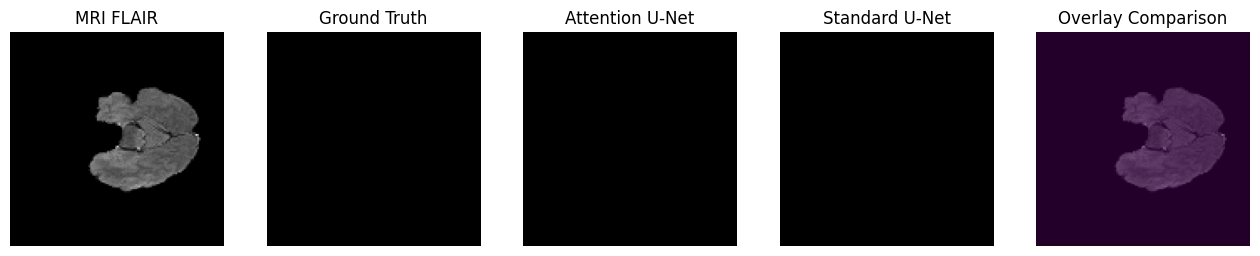

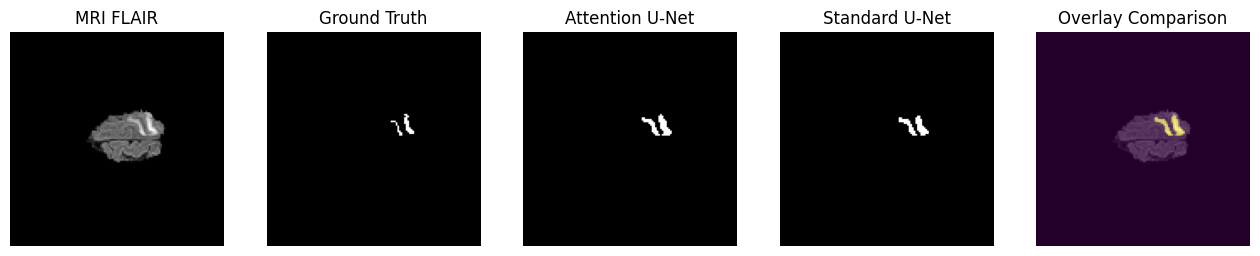

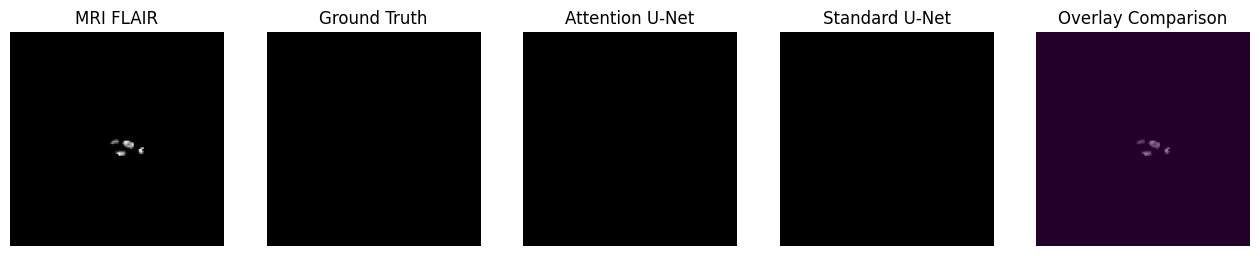

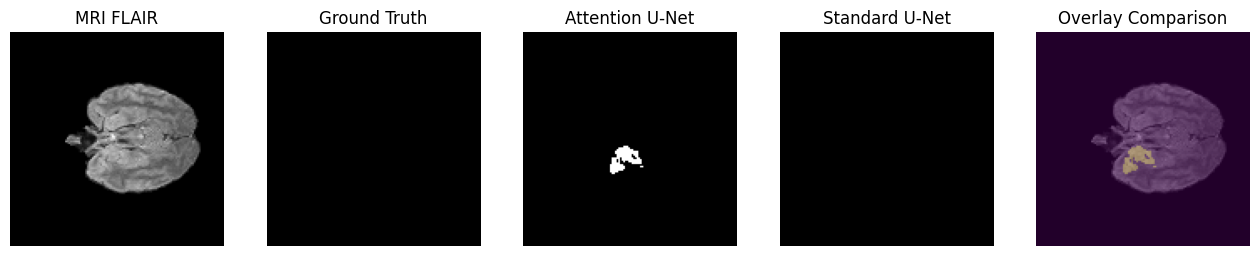

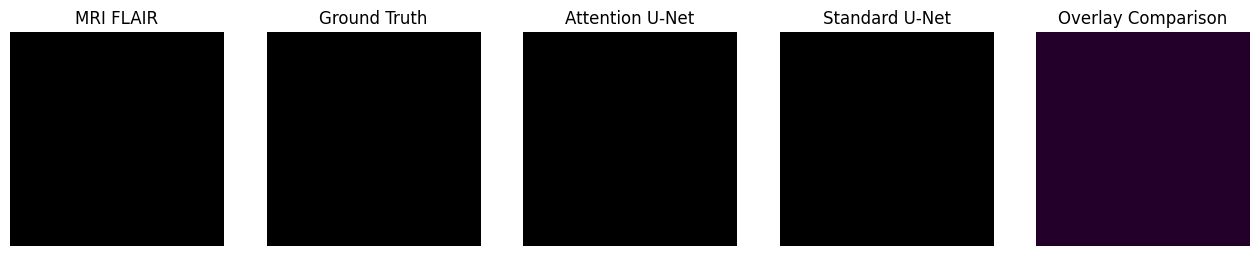


Brain Tumor Segmentation Model Comparison

Main Model: Attention U-Net
Comparison Model: Standard U-Net
Dataset: BraTS 2020 H5 slice format

Attention U-Net Test Results:
{
    "loss": 0.2423175424337387,
    "compile_metrics": 0.7663708925247192
}

Loaded Attention U-Net Test Results:
{
    "loss": 0.2423175424337387,
    "compile_metrics": 0.7663708925247192
}

Standard U-Net Test Results:
{
    "loss": 0.21949324011802673,
    "compile_metrics": 0.7881420254707336
}

Interpretation:
Standard U-Net is used as the baseline segmentation model. Attention U-Net is expected to improve tumor-region focus by using attention gates on skip connections.



In [29]:
# ==========================================================
# Section 16: Test Standard U-Net and Compare with Attention U-Net
# ==========================================================

unet_test_results = unet_model.evaluate(test_ds, verbose=1)
unet_metrics_dict = {name: float(value) for name, value in zip(unet_model.metrics_names, unet_test_results)}

print('\nStandard U-Net Testing Results')
for k, v in unet_metrics_dict.items():
    print(f'{k}: {v:.4f}')

with open(os.path.join(OUTPUT_DIR, 'standard_unet_test_metrics.json'), 'w') as f:
    json.dump(unet_metrics_dict, f, indent=4)

comparison_metrics = {
    'Attention_UNet': metrics_dict,
    'Loaded_Attention_UNet': loaded_metrics_dict,
    'Standard_UNet': unet_metrics_dict
}

with open(os.path.join(OUTPUT_DIR, 'attention_unet_vs_standard_unet_comparison.json'), 'w') as f:
    json.dump(comparison_metrics, f, indent=4)

# Comparison bar charts for key test metrics
comparison_names = ['Attention U-Net', 'Standard U-Net']
for metric_name in ['dice_coef', 'iou_coef', 'binary_accuracy']:
    att_value = metrics_dict.get(metric_name, None)
    unet_value = unet_metrics_dict.get(metric_name, None)
    if att_value is not None and unet_value is not None:
        plt.figure(figsize=(6, 5))
        plt.bar(comparison_names, [att_value, unet_value])
        plt.ylim(0, 1)
        plt.ylabel(metric_name)
        plt.title(f'Attention U-Net vs Standard U-Net: {metric_name}')
        plt.grid(axis='y')
        plt.savefig(os.path.join(OUTPUT_DIR, f'comparison_{metric_name}.png'), dpi=300, bbox_inches='tight')
        plt.show()

# Visual comparison on random test images

def compare_attention_and_unet_random_images(num_images=5, threshold=0.5):
    random_files = random.sample(test_files, min(num_images, len(test_files)))
    for idx, fpath in enumerate(random_files, start=1):
        image, mask = load_h5_file(fpath)
        att_pred = loaded_attention_model.predict(np.expand_dims(image, axis=0), verbose=0)[0]
        unet_pred = unet_model.predict(np.expand_dims(image, axis=0), verbose=0)[0]

        flair = image[:, :, 0]
        gt_mask = np.max(mask, axis=-1)
        att_mask = np.max((att_pred > threshold).astype(np.float32), axis=-1)
        unet_mask = np.max((unet_pred > threshold).astype(np.float32), axis=-1)

        plt.figure(figsize=(16, 4))
        plt.subplot(1, 5, 1)
        plt.imshow(flair, cmap='gray')
        plt.title('MRI FLAIR')
        plt.axis('off')

        plt.subplot(1, 5, 2)
        plt.imshow(gt_mask, cmap='gray')
        plt.title('Ground Truth')
        plt.axis('off')

        plt.subplot(1, 5, 3)
        plt.imshow(att_mask, cmap='gray')
        plt.title('Attention U-Net')
        plt.axis('off')

        plt.subplot(1, 5, 4)
        plt.imshow(unet_mask, cmap='gray')
        plt.title('Standard U-Net')
        plt.axis('off')

        plt.subplot(1, 5, 5)
        plt.imshow(flair, cmap='gray')
        plt.imshow(att_mask, alpha=0.35)
        plt.imshow(unet_mask, alpha=0.25)
        plt.title('Overlay Comparison')
        plt.axis('off')

        save_path = os.path.join(OUTPUT_DIR, f'attention_vs_unet_random_test_{idx}.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

compare_attention_and_unet_random_images(num_images=5)

comparison_summary = f"""
Brain Tumor Segmentation Model Comparison

Main Model: Attention U-Net
Comparison Model: Standard U-Net
Dataset: BraTS 2020 H5 slice format

Attention U-Net Test Results:
{json.dumps(metrics_dict, indent=4)}

Loaded Attention U-Net Test Results:
{json.dumps(loaded_metrics_dict, indent=4)}

Standard U-Net Test Results:
{json.dumps(unet_metrics_dict, indent=4)}

Interpretation:
Standard U-Net is used as the baseline segmentation model. Attention U-Net is expected to improve tumor-region focus by using attention gates on skip connections.
"""

with open(os.path.join(OUTPUT_DIR, 'final_model_comparison_summary.txt'), 'w') as f:
    f.write(comparison_summary)

print(comparison_summary)


In [30]:
# ==========================================================
# Section 17: Create ZIP File for Kaggle Download
# ==========================================================

zip_path = "/kaggle/working/brats_attention_unet_complete_results.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, OUTPUT_DIR)
            zipf.write(file_path, arcname=arcname)

print("ZIP file created successfully:", zip_path)

from IPython.display import FileLink, display
display(FileLink(zip_path))


ZIP file created successfully: /kaggle/working/brats_attention_unet_complete_results.zip


/kaggle/working/brats_attention_unet_complete_results.zip